# Customer lifetime value: the subscriber base as an absorbing chain

The loan book in notebook 02 and the AI agent in notebook 04 are both
systems I meet through projects. This notebook applies the same
machinery to the system that pays for everything else in a subscription
business: the customer base. It is written for the meeting where
someone asks "what is a customer actually worth?", "what would this
retention program earn?", or "which churn number should we attack
first?", and expects the answer in dollars rather than in adjectives.
The name for that first answer is customer lifetime value, CLV from
here on: the total margin a customer will contribute over the whole
relationship.

The setup will look familiar by now. A subscriber occupies one state
per month:

- **New**: in the first month after signing up
- **Active**: engaged and paying
- **At risk**: usage falling, payments late, complaint filed
- **Contract**: upgraded to a long-term contract. We stop tracking
  the relationship at that point and book its whole future as one lump
  value, the way finance books a present value, so the state is
  absorbing
- **Churned**: gone. Absorbing, and worth nothing

Two exits, three live states, one transition matrix. Nothing exotic
is needed to estimate one: any CRM that records each customer's
month-start and month-end state already contains the counts, and
row-normalizing them is the entire recipe. I made the rates below up,
but not their shape. High first-month churn, sticky actives, and a
save desk that wins about a third of its fights is what subscription
books tend to look like, and every technique here runs unchanged on
your own matrix.

Each live state also carries a monthly margin: a New customer on an
introductory price contributes about \$12 a month, an Active one
\$22, and an At-risk one \$10 as usage fades. Converting to a
contract books a one-time value of \$350. These five numbers plus the
matrix are the whole model.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

from markov import AbsorbingChain

np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

BLUE, ORANGE, GREEN = '#2a78d6', '#eb6834', '#1baf7a'
AMBER, RED, GRAY, INK = '#fab219', '#d03b3b', '#8a8f98', '#333333'

plt.rcParams.update({
    'figure.dpi': 100,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#666666', 'axes.linewidth': 0.9,
    'axes.grid': True, 'grid.alpha': 0.25,
    'axes.titlesize': 13, 'axes.titleweight': 'semibold',
    'axes.titlelocation': 'left', 'axes.titlecolor': INK,
    'axes.labelsize': 11, 'axes.labelcolor': '#444444',
    'xtick.color': '#666666', 'ytick.color': '#666666',
    'legend.frameon': False, 'font.size': 11,
})

states = ['New', 'Active', 'At risk', 'Contract', 'Churned']
P = np.array([
    [0.00, 0.70, 0.15, 0.03, 0.12],   # New
    [0.00, 0.88, 0.06, 0.02, 0.04],   # Active
    [0.00, 0.35, 0.40, 0.00, 0.25],   # At risk
    [0.00, 0.00, 0.00, 1.00, 0.00],   # Contract (absorbing)
    [0.00, 0.00, 0.00, 0.00, 1.00],   # Churned  (absorbing)
])
margin = np.array([12.0, 22.0, 10.0])     # $ per month in each live state
terminal = np.array([350.0, 0.0])         # one-time value: Contract, Churned

pd.DataFrame(P, index=states, columns=states)

,New,Active,At risk,Contract,Churned
New,0.0,0.70,0.15,0.03,0.12
Active,0.0,0.88,0.06,0.02,0.04
At risk,0.0,0.35,0.40,0.00,0.25
Contract,0.0,0.00,0.00,1.00,0.00
Churned,0.0,0.00,0.00,0.00,1.00


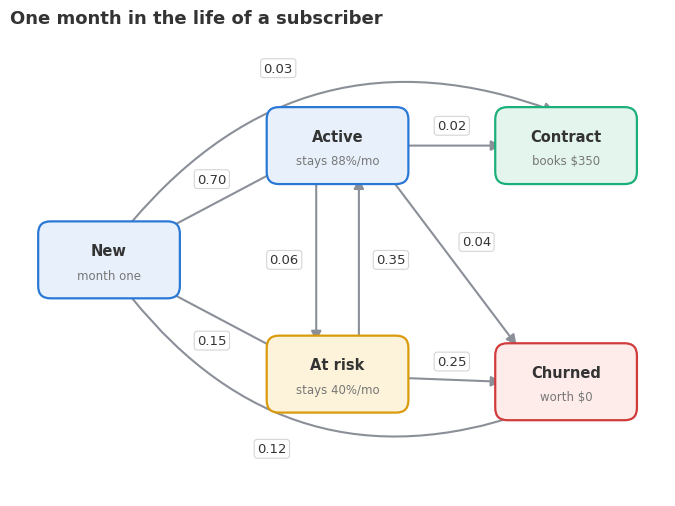

In [2]:
def add_box(ax, xy, w, text, face, edge, h=0.85, sub=None):
    ax.add_patch(mpatches.FancyBboxPatch(
        (xy[0] - w / 2, xy[1] - h / 2), w, h,
        boxstyle='round,pad=0.08,rounding_size=0.16',
        facecolor=face, edgecolor=edge, lw=1.6, zorder=3))
    dy = 0.12 if sub else 0.0
    ax.annotate(text, xy=(xy[0], xy[1] + dy), ha='center', va='center',
                fontsize=10.5, fontweight='semibold', color=INK, zorder=4)
    if sub:
        ax.annotate(sub, xy=(xy[0], xy[1] - 0.20), ha='center', va='center',
                    fontsize=8.5, color='#777777', zorder=4)

def add_arrow(ax, a, b, label=None, dx=0.0, dy=0.26, rad=0.0):
    style = f'arc3,rad={rad}' if rad else 'arc3'
    ax.add_patch(mpatches.FancyArrowPatch(
        a, b, connectionstyle=style, arrowstyle='-|>', mutation_scale=15,
        lw=1.5, color=GRAY, shrinkA=0, shrinkB=0, zorder=2))
    if label:
        u = np.subtract(b, a)
        side = np.array([u[1], -u[0]])
        mid = (np.add(a, b) / 2 + side * rad / 2
               + np.array([dx, dy]))
        ax.annotate(label, xy=mid, ha='center', va='center', fontsize=9.5,
                    color=INK, zorder=5,
                    bbox=dict(boxstyle='round,pad=0.22', facecolor='white',
                              edgecolor='#d5d5d5', lw=0.8))

fig, ax = plt.subplots(figsize=(11.5, 5.2))
add_box(ax, (0, 0), 1.7, 'New', '#e8f1fb', BLUE, sub='month one')
add_box(ax, (3, 1.5), 1.7, 'Active', '#e8f1fb', BLUE, sub='stays 88%/mo')
add_box(ax, (3, -1.5), 1.7, 'At risk', '#fdf3da', '#d99b0b',
        sub='stays 40%/mo')
add_box(ax, (6, 1.5), 1.7, 'Contract', '#e3f5ec', GREEN, sub='books $350')
add_box(ax, (6, -1.6), 1.7, 'Churned', '#fdecea', RED, sub='worth $0')

add_arrow(ax, (0.65, 0.35), (2.35, 1.25), '0.70', dx=-0.15)
add_arrow(ax, (0.65, -0.35), (2.35, -1.25), '0.15', dx=-0.15, dy=-0.26)
add_arrow(ax, (2.72, 1.07), (2.72, -1.07), '0.06', dx=-0.42, dy=0)
add_arrow(ax, (3.28, -1.07), (3.28, 1.07), '0.35', dx=0.42, dy=0)
add_arrow(ax, (3.85, 1.5), (5.15, 1.5), '0.02')
add_arrow(ax, (3.7, 1.07), (5.35, -1.12), '0.04', dx=0.3)
add_arrow(ax, (3.85, -1.55), (5.15, -1.6), '0.25', dy=0.24)
add_arrow(ax, (0.3, 0.5), (5.85, 1.95), '0.03', rad=-0.35, dx=-0.6, dy=0.32)
add_arrow(ax, (0.3, -0.5), (5.5, -2.0), '0.12', rad=0.35, dx=-0.5, dy=-0.32)

ax.set_xlim(-1.3, 7.3)
ax.set_ylim(-3.1, 3.0)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('One month in the life of a subscriber', pad=6)
fig.tight_layout()

Read the arrows the way an operator would, because each one is a
business motion with a team attached to it. The 0.12 on the low road is
early-life churn: one new customer in eight leaves within the first
month, before ever settling in, which is why onboarding teams exist.
The 0.35 climbing back from At risk is the save desk doing its job, and
the 0.25 leaving At risk downward is the save desk failing. The 0.02
trickle into Contract is the upsell motion. Every initiative your
company runs is an attempt to move one of these numbers, and by the end
of this notebook each such move will have a dollar value attached.

## What happens to a cohort

Start 100% of probability mass in New and push it forward a month at a
time with `mix @ P`, exactly as in notebook 02. This is the chain's
version of the cohort retention curve every subscription dashboard
shows.

still paying at month  3: 70.5%
still paying at month  6: 54.8%
still paying at month 12: 33.3%
still paying at month 24: 12.3%


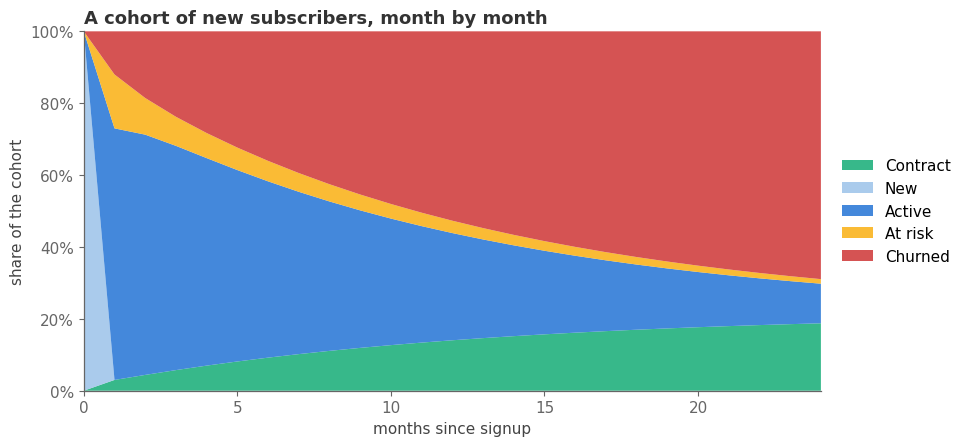

In [3]:
horizon = 25
mix = np.array([1.0, 0, 0, 0, 0])
rows = [mix.copy()]
for _ in range(horizon - 1):
    mix = mix @ P
    rows.append(mix.copy())
cohort = pd.DataFrame(rows, columns=states).rename_axis('month')

fig, ax = plt.subplots(figsize=(9.8, 4.6))
ax.stackplot(cohort.index,
             cohort['Contract'], cohort['New'], cohort['Active'],
             cohort['At risk'], cohort['Churned'],
             labels=['Contract', 'New', 'Active', 'At risk', 'Churned'],
             colors=[GREEN, '#9ec4ea', BLUE, AMBER, RED], alpha=0.88)
ax.set_xlim(0, horizon - 1)
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xlabel('months since signup')
ax.set_ylabel('share of the cohort')
ax.set_title('A cohort of new subscribers, month by month')
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5))
ax.grid(False)
fig.tight_layout()

alive = cohort[['New', 'Active', 'At risk']].sum(axis=1)
for m in (3, 6, 12, 24):
    print(f"still paying at month {m:>2}: {alive[m]:.1%}")

The shape is the one every operator knows: a steep early cliff, then a
long grind. Seventy percent of the cohort is still paying at month
three, a third at the one-year mark, and an eighth is still paying
after two years, with the green contract sliver growing slowly at the
bottom.

Dashboards usually compress this whole picture into one number, a
monthly churn or attrition rate, and the chain shows what that
compression hides. The cohort's attrition hazard (the chance that a
customer who was still paying last month leaves this month, through
either exit) is not constant: it starts high because month one is
dangerous, then settles as the surviving mix becomes mostly sticky
Actives.

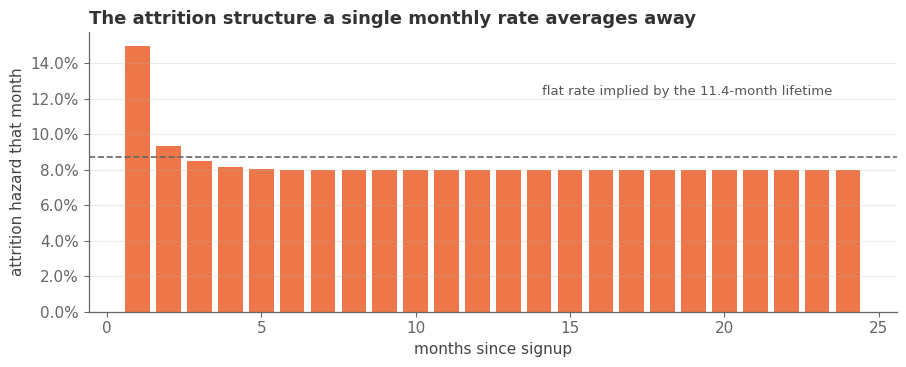

In [4]:
absorbed = cohort['Churned'] + cohort['Contract']
hazard = []
for m in range(1, horizon):
    left = absorbed[m] - absorbed[m - 1]
    hazard.append(left / alive[m - 1])

flat = 1 / 11.44   # a flat hazard with the same expected lifetime

fig, ax = plt.subplots(figsize=(9.2, 3.8))
ax.bar(range(1, horizon), np.array(hazard) * 100, color=ORANGE, alpha=0.9)
ax.axhline(flat * 100, color='#666666', ls='--', lw=1.2)
ax.annotate('flat rate implied by the 11.4-month lifetime',
            xy=(horizon - 1.5, flat * 100), xytext=(horizon - 1.5, 12.2),
            ha='right', fontsize=9.5, color='#555555')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_xlabel('months since signup')
ax.set_ylabel('attrition hazard that month')
ax.set_title('The attrition structure a single monthly rate averages away')
ax.grid(axis='y', alpha=0.25)
ax.grid(axis='x', alpha=0)
fig.tight_layout()

## The fundamental matrix, now denominated in months

Time to stop iterating and ask the exact questions. `AbsorbingChain`
splits the matrix, inverts $I - Q$, and hands back the three answers we
already trust from notebook 02, except every unit is now a
customer-month, which is to say money waiting to be multiplied.

In [5]:
chain = AbsorbingChain(P, states)
N = chain.N
B = chain.absorption_probabilities()

print("N, expected months in each live state:")
display(pd.DataFrame(N, index=chain.transient_states,
                     columns=chain.transient_states).round(2))

print("expected paying lifetime, months:")
for s, t in zip(chain.transient_states, chain.expected_steps()):
    print(f"  starting as {s}: {t:5.2f}")

print("\nB, how the relationship ends:")
display(pd.DataFrame(B, index=chain.transient_states,
                     columns=chain.absorbing_states).round(3))

N, expected months in each live state:


,New,Active,At risk
New,1.0,9.26,1.18
Active,-0.0,11.76,1.18
At risk,0.0,6.86,2.35


expected paying lifetime, months:
  starting as New: 11.44
  starting as Active: 12.94
  starting as At risk:  9.22

B, how the relationship ends:


,Contract,Churned
New,0.215,0.785
Active,0.235,0.765
At risk,0.137,0.863


The New row is the biography of an average signup: one month as New,
9.3 months as an Active customer, 1.2 months At risk, an expected
paying lifetime of 11.4 months. Exactly one month as New is built into
the matrix, since no arrow ever returns there (the New column of $P$
is all zeros), and the -0.0 in the table is floating point's way of
writing zero. About 21.5% of new customers eventually land the
contract upgrade; the other 78.5% churn. Notice also the At-risk row:
even from the danger state, a customer still has 9.2 expected paying
months ahead (2.4 of them in the At-risk state itself, most of the
rest back as an Active) and a one-in-seven chance of ending in a
contract, which is exactly why save desks are worth funding.

## From months to dollars

CLV drops out in one line. Months spent in each state times the margin
earned there, plus the probability of each ending times what that
ending is worth:

$$\text{CLV} = N c + B v$$

where $c$ is the monthly margin vector and $v$ the terminal values.
And because this series does not publish unverified numbers, a Monte
Carlo second witness walks thousands of simulated customers through the
matrix, accumulating actual margins along the way, sharing no algebra
with the formula.

In [6]:
clv = N @ margin + B @ terminal
for s, v in zip(chain.transient_states, clv):
    print(f"CLV starting as {s:<8}: ${v:6.2f}")

rng = np.random.default_rng(7)
def simulate_clv(start, n_runs=40_000):
    """Accumulate real margins along simulated customer paths."""
    i0 = states.index(start)
    values = np.zeros(n_runs)
    for r_ in range(n_runs):
        i, value = i0, 0.0
        while i < 3:                        # live states are 0, 1, 2
            value += margin[i]
            i = rng.choice(5, p=P[i])
        if i == 3:
            value += terminal[0]
        values[r_] = value
    return values.mean(), values.std() / np.sqrt(n_runs)

mc, se = simulate_clv('New')
print(f"\nMonte Carlo, 40k customers: ${mc:.2f} "
      f"with standard error {se:.2f}  (algebra said ${clv[0]:.2f})")

CLV starting as New     : $302.94
CLV starting as Active  : $352.94
CLV starting as At risk : $222.55



Monte Carlo, 40k customers: $306.20 with standard error 1.48  (algebra said $302.94)


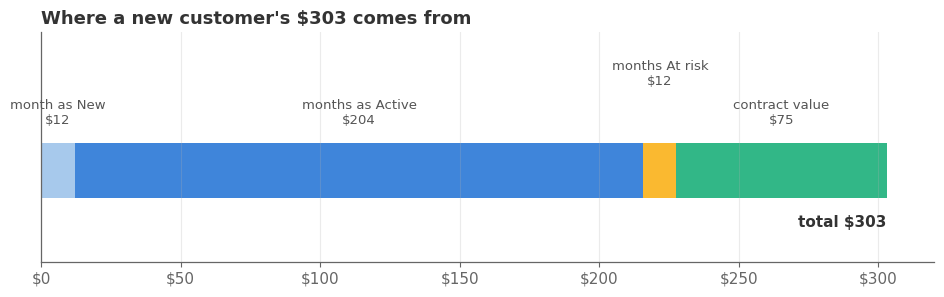

In [7]:
parts = pd.Series({
    'month as New': N[0, 0] * margin[0],
    'months as Active': N[0, 1] * margin[1],
    'months At risk': N[0, 2] * margin[2],
    'contract value': B[0, 0] * terminal[0],
})

fig, ax = plt.subplots(figsize=(9.6, 3.1))
left = 0.0
label_y = [0.62, 0.62, 1.05, 0.62]          # lift the narrow At-risk label
for (name, v), color, ly in zip(parts.items(),
                                ['#9ec4ea', BLUE, AMBER, GREEN], label_y):
    ax.barh([0], [v], left=left, color=color, alpha=0.9, height=0.6)
    ax.annotate(f'{name}\n${v:.0f}', xy=(left + v / 2, ly),
                ha='center', va='center', fontsize=9.5, color='#555555')
    left += v
ax.annotate(f'total ${left:.0f}', xy=(left, -0.62), ha='right',
            fontsize=11, fontweight='semibold', color=INK)
ax.set_xlim(0, 320)
ax.set_ylim(-1.0, 1.5)
ax.set_yticks([])
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
ax.set_title('Where a new customer\'s $303 comes from')
ax.grid(axis='x', alpha=0.25)
ax.grid(axis='y', alpha=0)
fig.tight_layout()

The dice landed within a couple of standard errors of the algebra,
which is what agreement looks like when one of your witnesses is
random. With the number trusted, read the decomposition. A new
customer is worth about \$303, and two thirds of that is ordinary
Active months. An Active customer is worth \$353 (their risky first
month is behind them) and even an At-risk customer still carries
\$223 of expected value, a number worth remembering the next time
someone proposes ignoring the at-risk queue because "they mostly
leave anyway".

One refinement before spending these numbers: finance will correctly
object that a dollar twelve months from now is not a dollar today.
Discounting slots straight into the algebra, and notebook 02's
geometric series says why. Expected visits were
$N = I + Q + Q^2 + \cdots$, one term per month; paying month $k$ at a
discount of $d^k$ turns the sum into $I + dQ + (dQ)^2 + \cdots$,
which collapses the same way to $(I - dQ)^{-1}$. Discount the exit
values by the same logic. The class does not need to know: it is
three lines of numpy.

In [8]:
d = 0.995                                  # roughly 6% a year
Nd = np.linalg.inv(np.eye(3) - d * chain.Q)
clv_d = Nd @ margin + (Nd @ (d * chain.R)) @ terminal

comparison = pd.DataFrame({'undiscounted': clv, 'discounted at 6%/yr': clv_d},
                          index=chain.transient_states)
comparison.round(2)

,undiscounted,discounted at 6%/yr
New,302.94,285.89
Active,352.94,333.35
At risk,222.55,209.45


Between five and six percent comes off, most for the At-risk state,
whose value mostly arrives only after a recovery to Active pushes it
deeper into the future. Everything below uses undiscounted numbers to
keep the arithmetic readable; in a real business case, run both.

## Pricing a retention program

Now the payoff: the meeting where this machinery earns its keep.

Proposal on the table. A retention program for at-risk customers:
proactive outreach, a discount offer, a dedicated queue. The believable
effect, benchmarked from a pilot, is that the save rate rises from 35%
to 45% a month and at-risk churn falls from 25% to 15%. The cost is
\$6 per at-risk customer per month while they sit in the queue.

The naive analysis prices the benefit times a guess at volume. The
chain prices the whole causal cascade: the edit changes the At-risk
row, which changes $N$, which changes lifetimes, contract rates, CLV,
*and* the program's own cost base, since $N$ also counts how many
at-risk months the program will be paid for. One matrix edit, then read
everything off.

In [9]:
P_prog = P.copy()
P_prog[2] = [0.00, 0.45, 0.40, 0.00, 0.15]

prog = AbsorbingChain(P_prog, states)
clv_prog = prog.N @ margin + prog.absorption_probabilities() @ terminal

risk_months = prog.N[0, 2]                 # at-risk months per new customer
program_cost = 6.0 * risk_months
uplift = clv_prog[0] - clv[0]
net = uplift - program_cost

print(f"CLV of a new customer : ${clv[0]:6.2f}  ->  ${clv_prog[0]:6.2f}")
print(f"expected lifetime     : {chain.expected_steps()[0]:5.2f} -> "
      f"{prog.expected_steps()[0]:5.2f} months")
print(f"at-risk months funded : {N[0, 2]:.2f} -> {risk_months:.2f}")
print(f"\ngross uplift per new customer : ${uplift:6.2f}")
print(f"program cost per new customer : ${program_cost:6.2f}")
print(f"net value per new customer    : ${net:6.2f}")
print(f"\nbreak-even cost per at-risk month: ${uplift / risk_months:.2f}")
print(f"on a cohort of 100,000 signups a year: "
      f"${net * 100_000 / 1e6:.1f}M of net value")

CLV of a new customer : $302.94  ->  $350.00
expected lifetime     : 11.44 -> 13.17 months
at-risk months funded : 1.18 -> 1.33

gross uplift per new customer : $ 47.06
program cost per new customer : $  8.00
net value per new customer    : $ 39.06

break-even cost per at-risk month: $35.29
on a cohort of 100,000 signups a year: $3.9M of net value


The program adds \$47 of gross value per new customer, costs
\$8, and nets about \$39, roughly \$3.9M a year on a hundred
thousand signups. (That the post-program CLV lands on \$350.00 to
the cent, the same figure as the contract value, is a coincidence of
these illustrative rates, not a mechanism.) Two details in the
computation deserve attention because naive analyses miss both. The
cost side used the *post-program* $N$: a program that keeps customers
alive longer also keeps them in the at-risk queue longer, so it partly
funds itself into higher costs, and the chain accounts for that
automatically. And the break-even number says the \$6 assumption
has room to be almost six times too optimistic before the program
destroys value, which is the sentence a decision maker actually
needs.

## Which lever is worth pulling?

The retention program is one lever among several a subscription
business runs. Give each candidate initiative the same treatment, a
one-point edit to its transition, and rank them by CLV impact per new
customer.

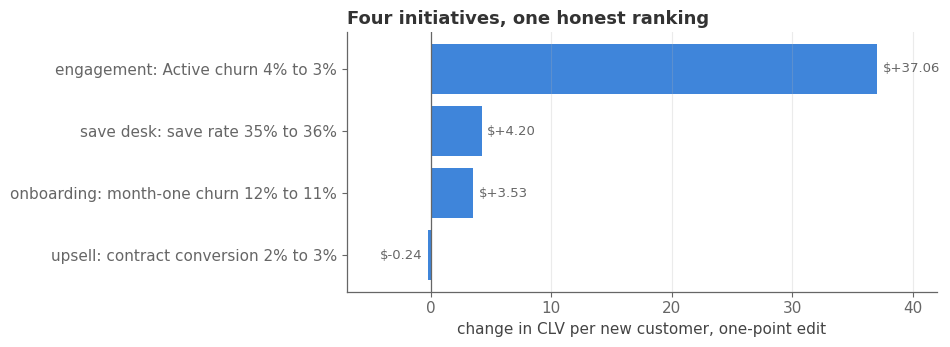

In [10]:
def clv_new(Pm):
    c = AbsorbingChain(Pm, states)
    return (c.N @ margin + c.absorption_probabilities() @ terminal)[0]

levers = {
    'onboarding: month-one churn 12% to 11%':
        [(0, 4, -0.01), (0, 1, +0.01)],
    'engagement: Active churn 4% to 3%':
        [(1, 4, -0.01), (1, 1, +0.01)],
    'save desk: save rate 35% to 36%':
        [(2, 4, -0.01), (2, 1, +0.01)],
    'upsell: contract conversion 2% to 3%':
        [(1, 1, -0.01), (1, 3, +0.01)],
}

base = clv_new(P)
gains = []
for name, ops in levers.items():
    Pm = P.copy()
    for i, j, dlt in ops:
        Pm[i, j] += dlt
    gains.append((name, clv_new(Pm) - base))
gains = pd.DataFrame(gains, columns=['lever', 'delta CLV']).sort_values('delta CLV')

fig, ax = plt.subplots(figsize=(9.6, 3.6))
bars = ax.barh(gains['lever'], gains['delta CLV'], color=BLUE, alpha=0.9)
ax.bar_label(bars, fmt='$%+.2f', fontsize=9.5, color='#666666', padding=4)
ax.axvline(0, color='#666666', lw=0.9)
ax.set_xlabel('change in CLV per new customer, one-point edit')
ax.set_title('Four initiatives, one honest ranking')
ax.set_xlim(-7, 42)
ax.grid(axis='x', alpha=0.25)
ax.grid(axis='y', alpha=0)
fig.tight_layout()

Two findings here justify the whole notebook.

**The engagement lever dominates by an order of magnitude.** A point
off Active churn is worth about \$37 per new customer; a point of
onboarding improvement or save-desk improvement is worth \$3.50 to
\$4.20. The reason is occupancy, the same weakest-link logic
notebook 04 found in agent pipelines but denominated in dollars: a
customer spends 9.3 of their 11.4 months in Active, so a point of
monthly leakage there is charged against far more customer-months than
a point anywhere else. Churn dashboards that report rates without
occupancy weights rank levers wrong.

**The upsell lever is worth nothing.** Pushing contract conversion
from 2% to 3% moves CLV by minus 24 cents, effectively zero, and the
chain says why: converting an Active customer books \$350 but
removes a customer whose expected remaining value was \$353. The
bonus is priced at almost exactly the value it cannibalizes. A sales
team could hit that conversion target all year and the business would
not be a dollar richer, unless the contract's value rises or
conversion pulls from At risk instead of Active. That is not an
intuition anyone carries in their head; it fell out of one matrix
multiplication.

One caveat belongs next to this chart whenever a decision maker sees
it: the ranking prices the value of each point, not the cost of buying
one, and a point of churn across the whole Active base is usually the
most expensive point on the chart. The ranking sets the order of
investigation; each lever still needs its own cost case, the way the
retention program got one above.

## Honest limits

1. **One matrix, many customers.** Averaging over segments hides that
   a student prepaid line and an enterprise family plan migrate
   nothing alike. Real deployments fit a matrix per segment and roll
   up; everything here survives that split unchanged.
2. **Rates drift.** Competitor launches, price changes, and macro
   shifts move the matrix, so it needs re-estimation on a schedule,
   with the notebook 03 lesson about frozen models in full force.
3. **Memorylessness is a modeling choice.** A customer on their third
   at-risk episode is not a first-timer. If your CRM says history
   matters, encode it in richer states ("At risk, repeat"), at the
   price of a bigger matrix.
4. **The inputs carry error bars.** Margins, the \$350 contract
   value, and every transition rate are estimates; the Monte Carlo harness
   above is the natural way to propagate their uncertainty into a CLV
   range instead of a false point.

## Takeaways

1. CLV comes out of one object: $Nc + Bv$, the fundamental matrix
   pricing customer-months and endings, with discounting a single
   substitution away.
2. Cohort curves, hazard structure, lifetimes, and conversion odds all
   come from the same five-state matrix, so they can never disagree
   with each other, which is more than most dashboards can claim.
3. Interventions are matrix edits, so they can be priced *before*
   launch, including second-order effects like a retention program
   inflating its own cost base.
4. Rank levers by dollars per edit, not by the size of the rate they
   move. Occupancy decides, and it put a 10x gap between two
   initiatives that sound equally worthy in a planning meeting.

This closes the loop the series opened: notebook 01 built the chain,
02 priced exits, 03 hid the states, 04 measured an AI agent, and this
one walked the same mathematics into a revenue meeting.

---

*Satsawat Natakarnkitkul · [satsawat.ai](https://satsawat.ai) ·
[AI in Practice newsletter](https://satsawat.ai/#newsletter)*